# Weather Data Analysis (Pressure < 600 mbar)
Load and visualize historical weather data from dump_tmpwx.csv - filtered to show only records where barometric pressure is less than 600 mbar

## Import Required Libraries
Import pandas for data manipulation, matplotlib for plotting, and other necessary libraries for data analysis.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)

## Load CSV Data
Read the dump_tmpwx.csv file using pandas read_csv() function and store it in a DataFrame.

In [56]:
# Load the CSV file
print("Loading CSV file...")
df = pd.read_csv('dump_tmpwx.csv')

# Convert Datetime column to datetime type (assuming UTC)
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Convert UTC to Chilean local time
df['Datetime'] = df['Datetime'].dt.tz_localize('UTC').dt.tz_convert('America/Santiago')

# Sort by datetime
df = df.sort_values('Datetime').reset_index(drop=True)

print(f"Data loaded successfully!")
print(f"Total records: {len(df)}")

Loading CSV file...
Data loaded successfully!
Total records: 333200


In [57]:
# Filter data where pressure < 600 mbar
print("Filtering data where Pressure < 600 mbar...")
df_filtered = df[df['BP_mbar_Avg'] < 600].copy()
print(f"Filtered records: {len(df_filtered)} out of {len(df)} total records")
print(f"Percentage of data: {len(df_filtered)/len(df)*100:.1f}%")

# Use filtered data for all plots
df = df_filtered
# ignore the first 10 records for better visualization
df = df.iloc[10:].reset_index(drop=True)

# Check for and handle negative/invalid wind speeds
wind_speed_columns = [col for col in df.columns if 'WS' in col]
print(f"\nWind speed columns: {wind_speed_columns}")

# First, identify rows with negative wind speeds (but keep NaN values)
mask = pd.Series([True] * len(df), index=df.index)
for col in wind_speed_columns:
    # Keep rows where column is >= 0 OR is NaN (we'll keep NaN for now)
    mask = mask & ((df[col] >= 0) | (df[col].isna()))



Filtering data where Pressure < 600 mbar...
Filtered records: 198733 out of 333200 total records
Percentage of data: 59.6%

Wind speed columns: ['WS_ms_Avg', 'WS_ms_Max', 'WS_ms_Min', 'WS_ms_S_WVT', 'WS_ms_2_Avg', 'WS_ms_2_Max', 'WS_ms_2_Min']


## Explore Data Structure
Display the first few rows, data types, column names, and basic statistics of the DataFrame to understand the data structure.

In [58]:
# Display basic information
print("Date range:")
print(f"  Start: {df['Datetime'].min()}")
print(f"  End: {df['Datetime'].max()}")
print(f"\nTotal span: {(df['Datetime'].max() - df['Datetime'].min()).days} days")
print(f"\nFirst few rows:")
print(df.head())

Date range:
  Start: 2022-10-07 09:10:00-03:00
  End: 2026-07-18 08:30:00-04:00

Total span: 1380 days

First few rows:
                   Datetime  RecNbr  BattV_Avg  PTemp_C_Avg  WS_ms_Avg  \
0 2022-10-07 09:10:00-03:00  134501      14.50       -1.188      6.881   
1 2022-10-07 09:20:00-03:00  134502      14.50       -1.410      4.794   
2 2022-10-07 09:30:00-03:00  134503      14.51       -1.469      5.622   
3 2022-10-07 09:40:00-03:00  134504      14.54       -1.435      4.855   
4 2022-10-07 09:50:00-03:00  134505      14.54       -1.391      5.537   

   WS_ms_Max  WS_ms_Min  WS_ms_S_WVT  WindDir_D1_WVT  WindDir_SD1_WVT  \
0      16.36      0.200        6.881          310.30            70.09   
1      11.76      0.100        4.794           30.03            86.50   
2      14.09      0.466        5.622           38.08            84.00   
3      12.86      0.033        4.855           13.74            78.59   
4      15.43      0.333        5.537          330.80            91.80 

In [27]:
# Display all column names
print("Available columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Available columns:
  1. Datetime
  2. RecNbr
  3. BattV_Avg
  4. PTemp_C_Avg
  5. WS_ms_Avg
  6. WS_ms_Max
  7. WS_ms_Min
  8. WS_ms_S_WVT
  9. WindDir_D1_WVT
  10. WindDir_SD1_WVT
  11. BP_mbar_Avg
  12. Temp_C_Avg
  13. WS_ms_2_Avg
  14. WS_ms_2_Max
  15. WS_ms_2_Min
  16. AirTC_Avg
  17. RH
  18. SlrkW_Avg
  19. CS320_Temp_Avg
  20. SlrMJ_Tot


In [28]:
# Display data types and missing values
print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198723 entries, 0 to 198722
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Datetime         198723 non-null  datetime64[ns]
 1   RecNbr           198723 non-null  int64         
 2   BattV_Avg        198723 non-null  float64       
 3   PTemp_C_Avg      198723 non-null  float64       
 4   WS_ms_Avg        198723 non-null  float64       
 5   WS_ms_Max        198723 non-null  float64       
 6   WS_ms_Min        198723 non-null  float64       
 7   WS_ms_S_WVT      198723 non-null  float64       
 8   WindDir_D1_WVT   198723 non-null  float64       
 9   WindDir_SD1_WVT  198723 non-null  float64       
 10  BP_mbar_Avg      198723 non-null  float64       
 11  Temp_C_Avg       198723 non-null  float64       
 12  WS_ms_2_Avg      198723 non-null  float64       
 13  WS_ms_2_Max      198723 non-null  float64       
 14  WS_ms_2_

In [29]:
# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
                            Datetime         RecNbr      BattV_Avg  \
count                         198723  198723.000000  198723.000000   
mean   2024-08-27 12:20:00.000001024  233862.000000      13.398791   
min              2022-10-07 12:10:00  134501.000000      11.800000   
25%              2023-09-17 12:15:00  184181.500000      12.710000   
50%              2024-08-27 12:20:00  233862.000000      12.890000   
75%              2025-08-07 12:25:00  283542.500000      14.350000   
max              2026-07-18 12:30:00  333223.000000      15.450000   
std                              NaN   57366.533109       0.831709   

         PTemp_C_Avg      WS_ms_Avg      WS_ms_Max      WS_ms_Min  \
count  198723.000000  198723.000000  198723.000000  198723.000000   
mean       -4.063266       4.712408       9.451062       1.474686   
min       -21.630000       0.000000     -14.060000      -0.300000   
25%        -8.260000       2.834000       6.497000       0.000000   
50

## Plot Temperature Timeline
Create a line plot showing the complete timeline of temperature data with appropriate labels, title, and formatting.

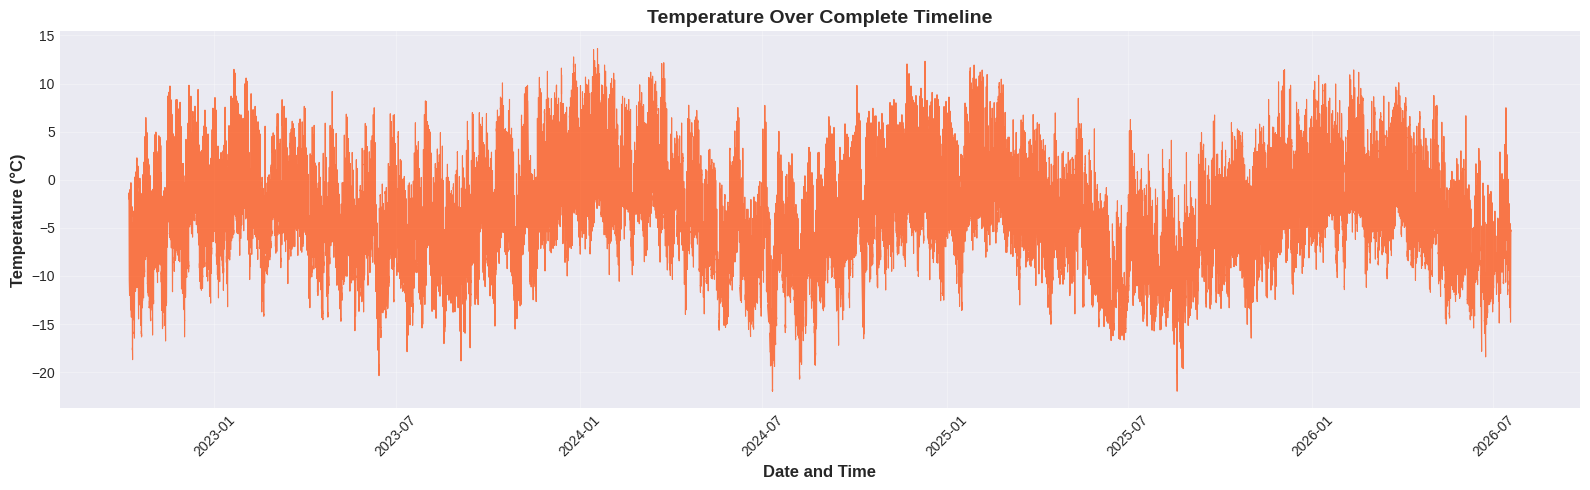

Temperature Statistics:
  Mean: -4.28°C
  Min:  -21.98°C
  Max:  13.65°C
  Std:  5.75°C


In [30]:
# Create figure for temperature
fig, ax = plt.subplots(figsize=(16, 5))

if 'Temp_C_Avg' in df.columns:
    ax.plot(df['Datetime'], df['Temp_C_Avg'], linewidth=0.8, color='orangered', alpha=0.7)
    ax.set_xlabel('Date and Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax.set_title('Temperature Over Complete Timeline', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Display temperature statistics
    print("Temperature Statistics:")
    print(f"  Mean: {df['Temp_C_Avg'].mean():.2f}°C")
    print(f"  Min:  {df['Temp_C_Avg'].min():.2f}°C")
    print(f"  Max:  {df['Temp_C_Avg'].max():.2f}°C")
    print(f"  Std:  {df['Temp_C_Avg'].std():.2f}°C")
else:
    print("Temperature column 'Temp_C_Avg' not found in data")

## Plot Wind Speed Timeline
Create a line plot showing the complete timeline of wind speed data with appropriate labels, title, and formatting.

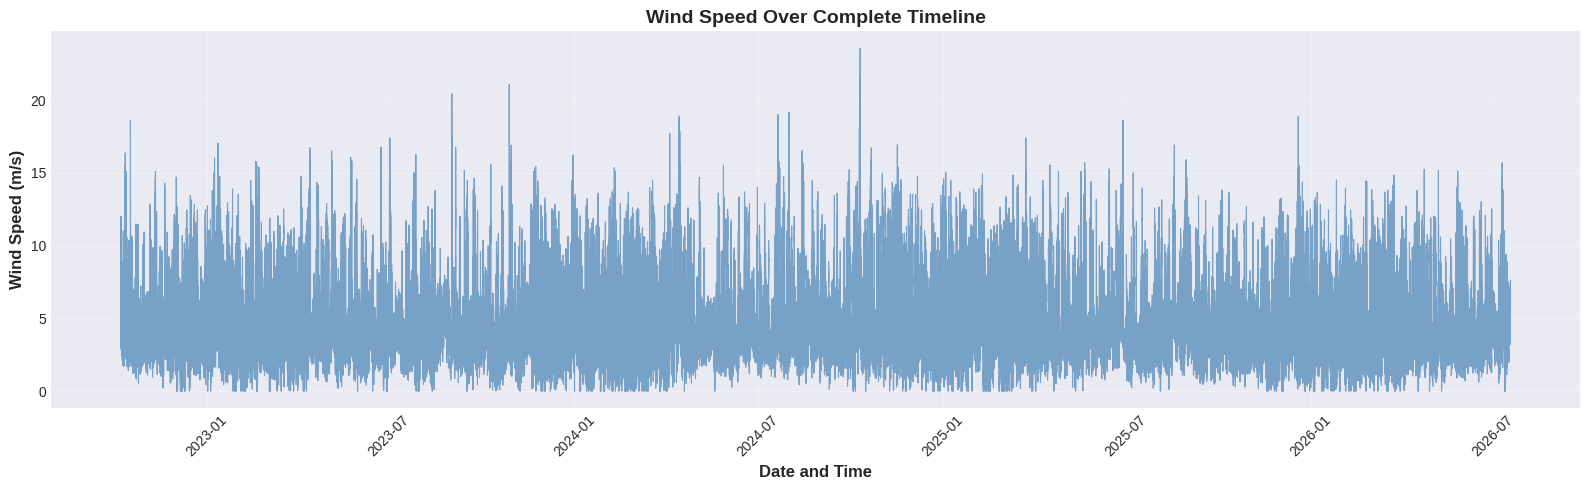

Wind Speed Statistics:
  Mean: 4.71 m/s
  Min:  0.00 m/s
  Max:  23.55 m/s
  Std:  2.67 m/s


In [31]:
# Create figure for wind speed
fig, ax = plt.subplots(figsize=(16, 5))

if 'WS_ms_Avg' in df.columns:
    ax.plot(df['Datetime'], df['WS_ms_Avg'], linewidth=0.8, color='steelblue', alpha=0.7)
    ax.set_xlabel('Date and Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
    ax.set_title('Wind Speed Over Complete Timeline', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Display wind speed statistics
    print("Wind Speed Statistics:")
    print(f"  Mean: {df['WS_ms_Avg'].mean():.2f} m/s")
    print(f"  Min:  {df['WS_ms_Avg'].min():.2f} m/s")
    print(f"  Max:  {df['WS_ms_Avg'].max():.2f} m/s")
    print(f"  Std:  {df['WS_ms_Avg'].std():.2f} m/s")
else:
    print("Wind Speed column 'WS_ms_Avg' not found in data")

## Plot Pressure Timeline
Create a line plot showing the complete timeline of pressure data with appropriate labels, title, and formatting.

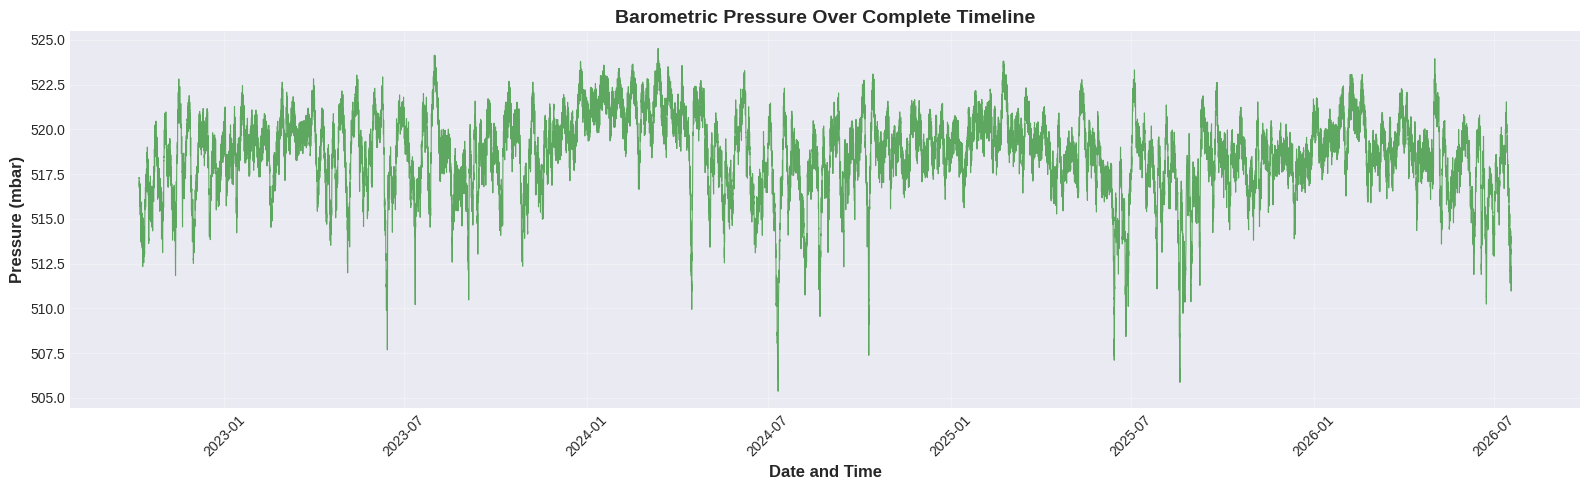

Barometric Pressure Statistics:
  Mean: 518.63 mbar
  Min:  505.37 mbar
  Max:  524.51 mbar
  Std:  2.21 mbar


In [32]:
# Create figure for pressure
fig, ax = plt.subplots(figsize=(16, 5))

if 'BP_mbar_Avg' in df.columns:
    ax.plot(df['Datetime'], df['BP_mbar_Avg'], linewidth=0.8, color='forestgreen', alpha=0.7)
    ax.set_xlabel('Date and Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Pressure (mbar)', fontsize=12, fontweight='bold')
    ax.set_title('Barometric Pressure Over Complete Timeline', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Display pressure statistics
    print("Barometric Pressure Statistics:")
    print(f"  Mean: {df['BP_mbar_Avg'].mean():.2f} mbar")
    print(f"  Min:  {df['BP_mbar_Avg'].min():.2f} mbar")
    print(f"  Max:  {df['BP_mbar_Avg'].max():.2f} mbar")
    print(f"  Std:  {df['BP_mbar_Avg'].std():.2f} mbar")
else:
    print("Pressure column 'BP_mbar_Avg' not found in data")

## Combined View: All Three Variables
Display temperature, wind speed, and pressure on the same figure with separate subplots.

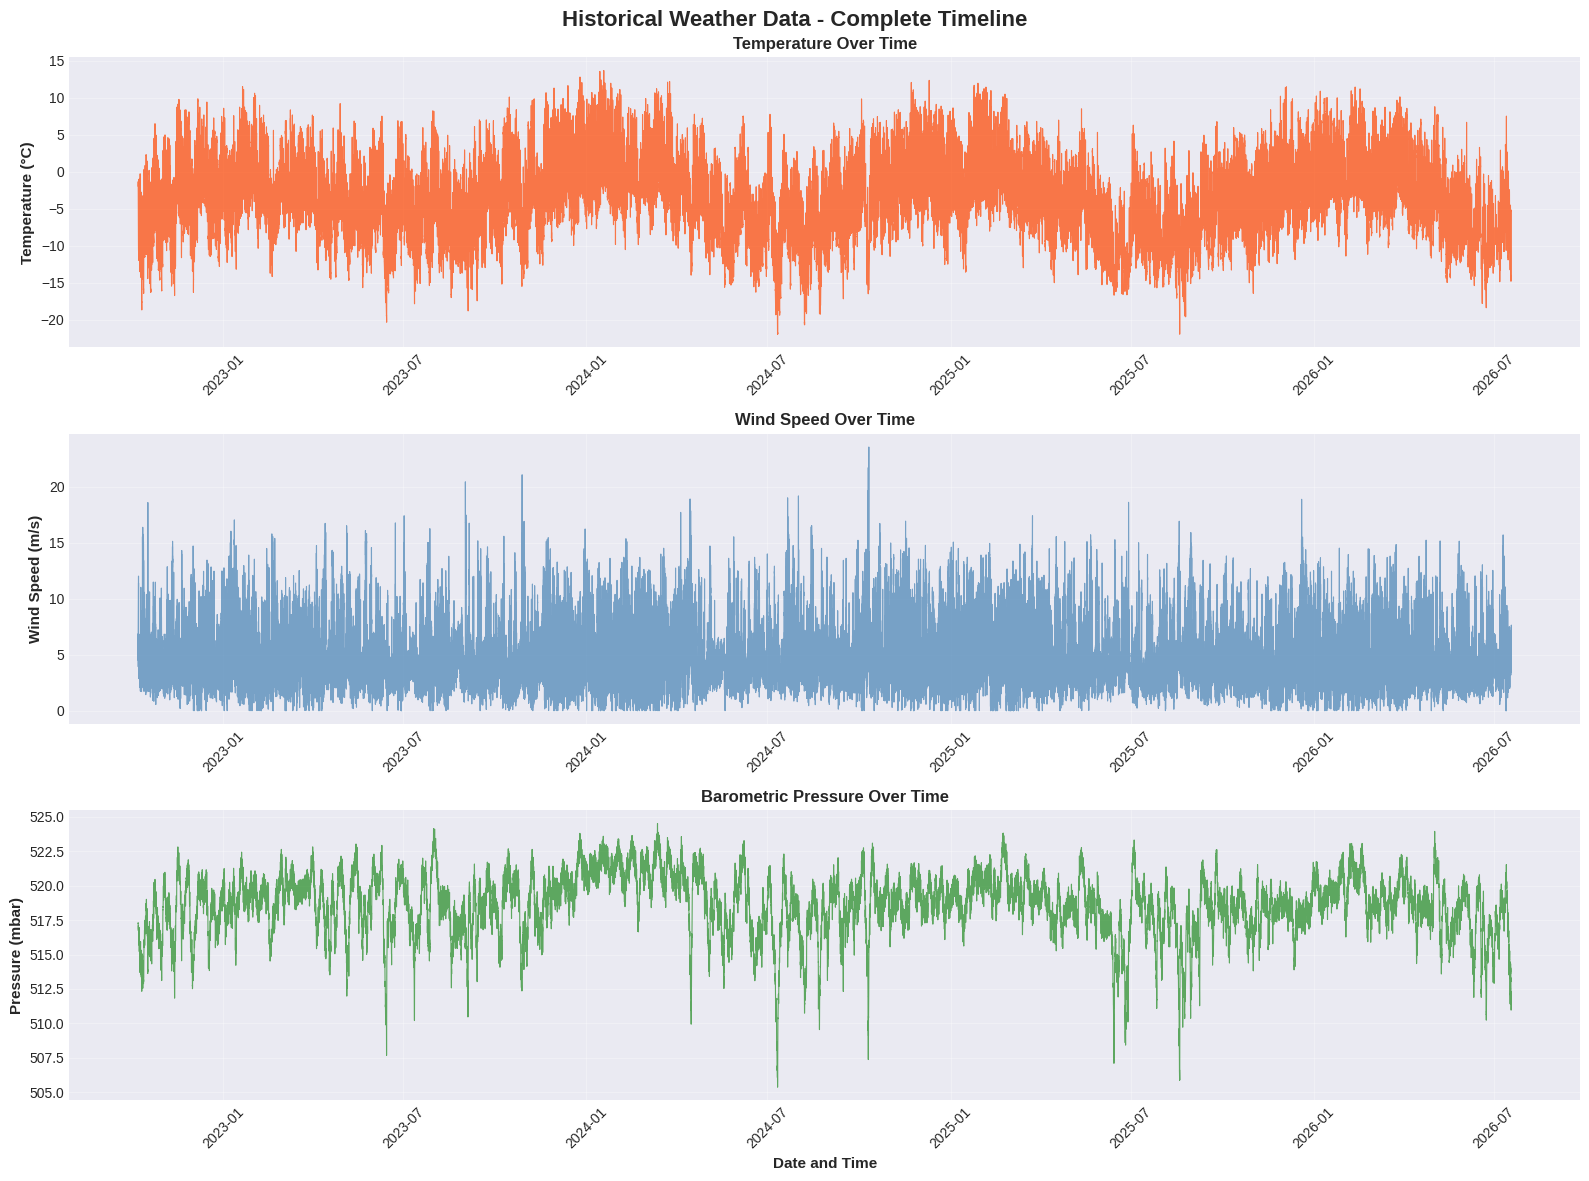

Combined plot saved as 'weather_timeline_combined.png'


In [33]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Historical Weather Data - Complete Timeline', fontsize=16, fontweight='bold')

# Plot 1: Temperature
if 'Temp_C_Avg' in df.columns:
    axes[0].plot(df['Datetime'], df['Temp_C_Avg'], linewidth=0.8, color='orangered', alpha=0.7)
    axes[0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
    axes[0].set_title('Temperature Over Time', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

# Plot 2: Wind Speed
if 'WS_ms_Avg' in df.columns:
    axes[1].plot(df['Datetime'], df['WS_ms_Avg'], linewidth=0.8, color='steelblue', alpha=0.7)
    axes[1].set_ylabel('Wind Speed (m/s)', fontsize=11, fontweight='bold')
    axes[1].set_title('Wind Speed Over Time', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

# Plot 3: Pressure
if 'BP_mbar_Avg' in df.columns:
    axes[2].plot(df['Datetime'], df['BP_mbar_Avg'], linewidth=0.8, color='forestgreen', alpha=0.7)
    axes[2].set_ylabel('Pressure (mbar)', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Date and Time', fontsize=11, fontweight='bold')
    axes[2].set_title('Barometric Pressure Over Time', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)

# Format x-axis for all plots
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('weather_timeline_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Combined plot saved as 'weather_timeline_combined.png'")

## Wind Speed Range with Error Bars
Create a plot showing wind speed with error bars representing the range between maximum and minimum wind speeds in each measurement period.

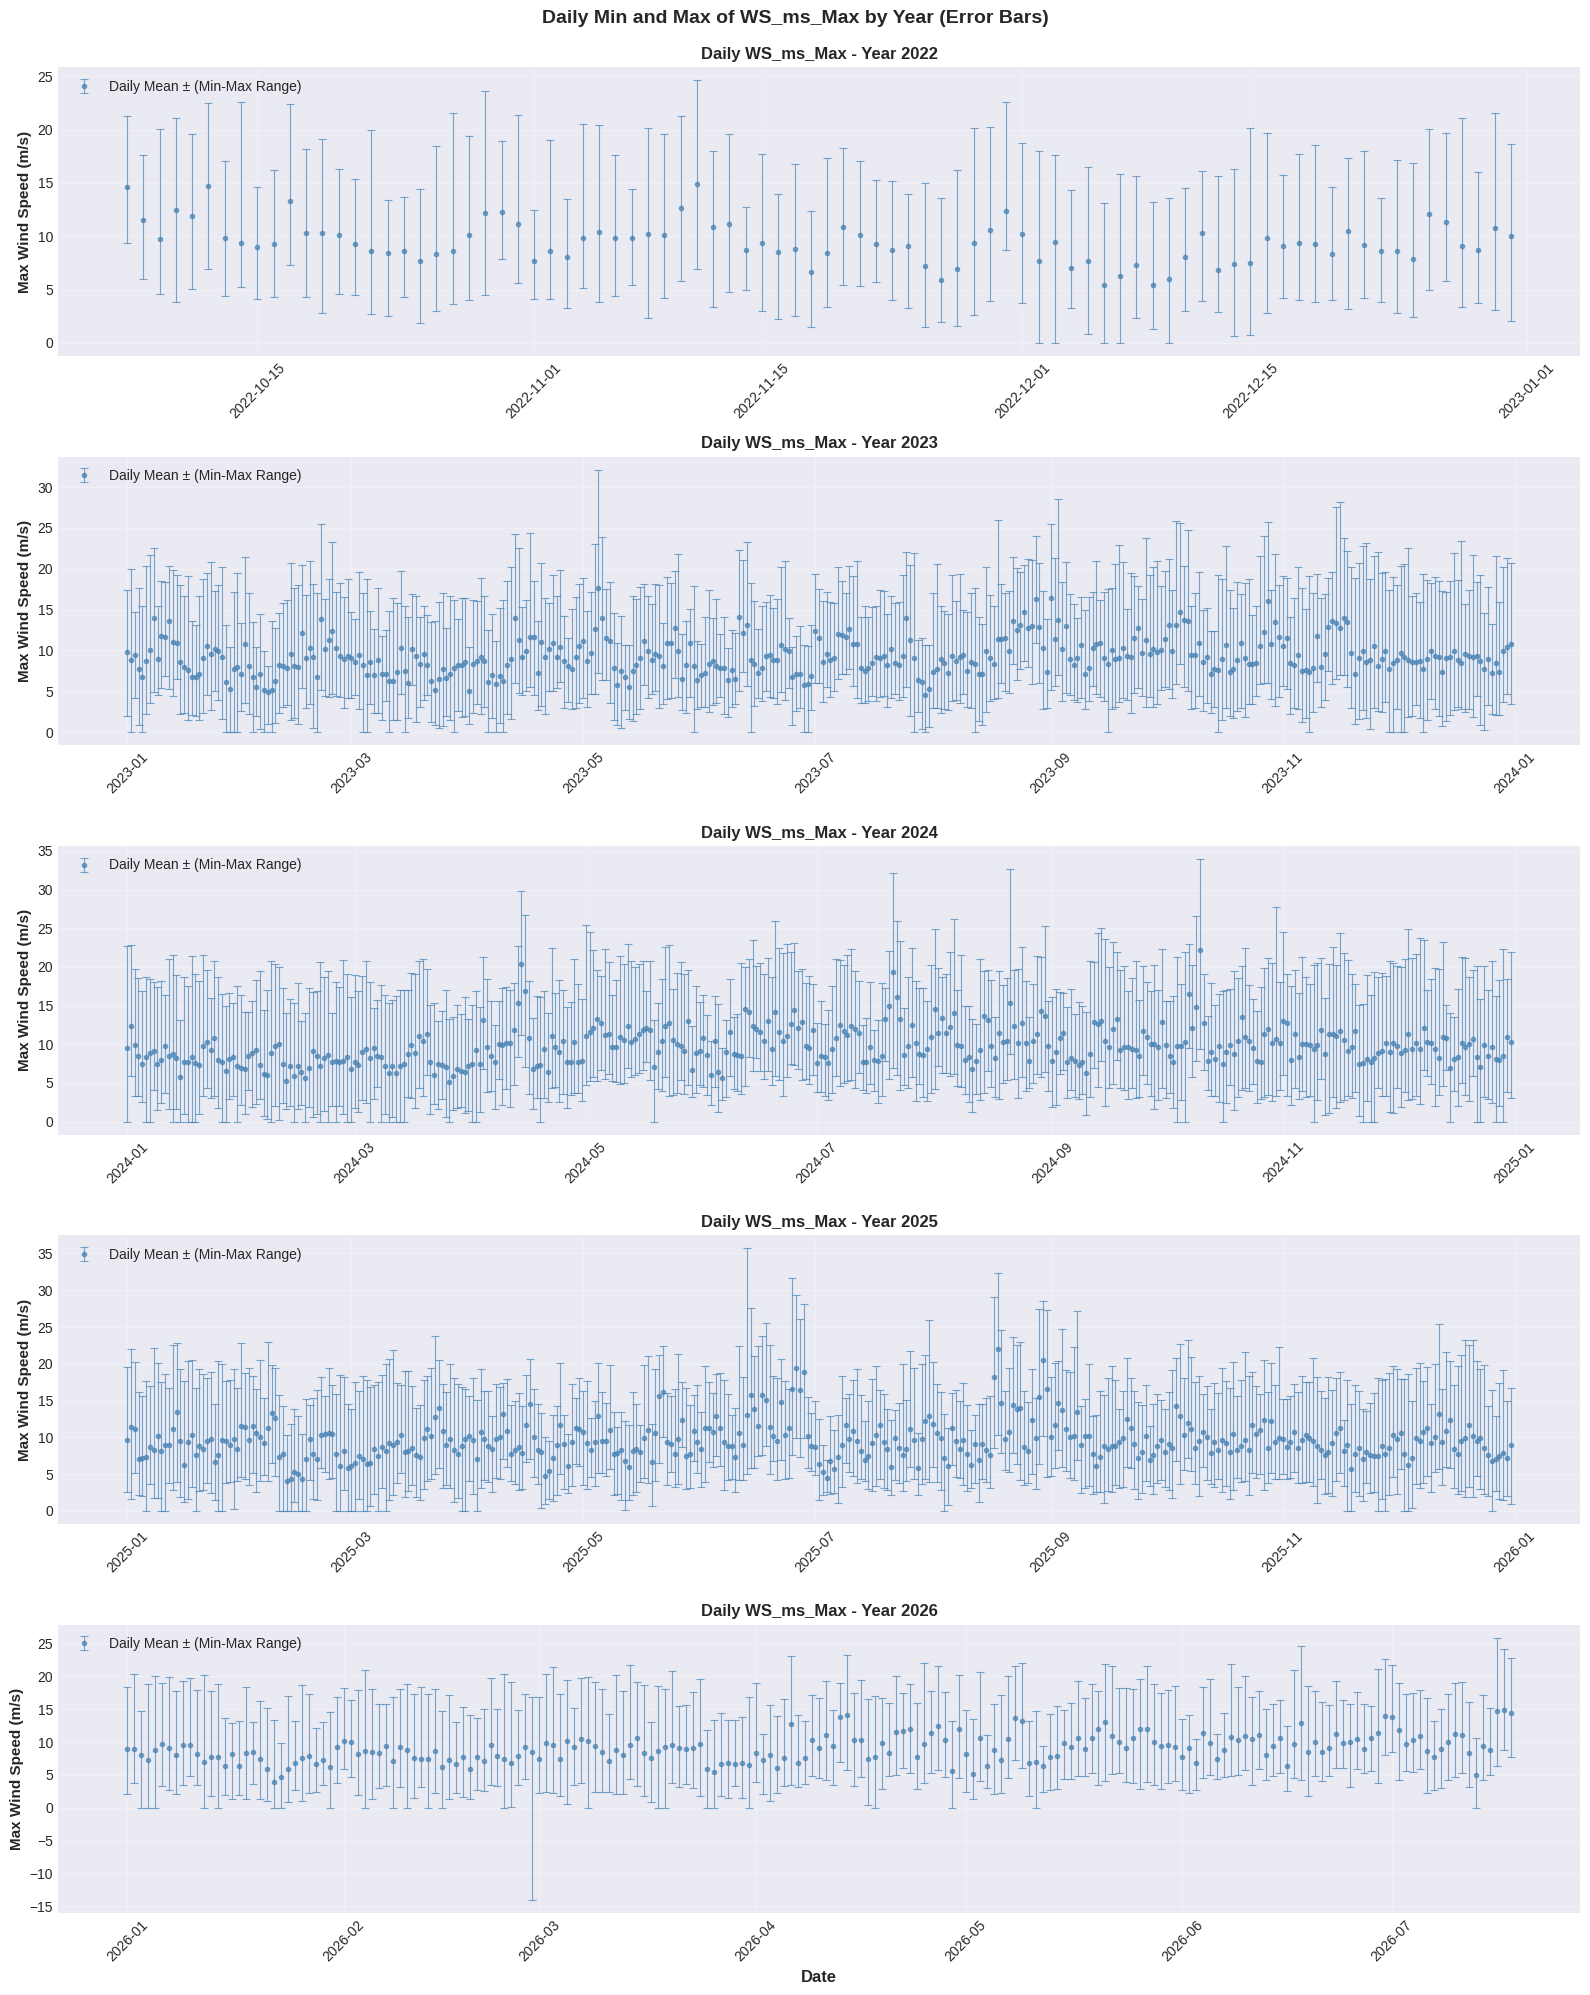

Daily WS_ms_Max Statistics by Year:

Year 2022:
  Daily Mean (m/s):
    Mean: 9.45
    Min:  5.41
    Max:  14.93
  Daily Min of WS_ms_Max (m/s):
    Mean: 3.69
    Min:  0.00
    Max:  9.40
  Daily Max of WS_ms_Max (m/s):
    Mean: 17.61
    Min:  12.40
    Max:  24.62
  Daily Range (Max - Min):
    Mean: 13.92 m/s
    Max:  19.43 m/s
  Days with data: 86

Year 2023:
  Daily Mean (m/s):
    Mean: 9.30
    Min:  4.54
    Max:  17.66
  Daily Min of WS_ms_Max (m/s):
    Mean: 3.29
    Min:  0.00
    Max:  10.86
  Daily Max of WS_ms_Max (m/s):
    Mean: 17.51
    Min:  8.13
    Max:  32.12
  Daily Range (Max - Min):
    Mean: 14.22 m/s
    Max:  24.92 m/s
  Days with data: 365

Year 2024:
  Daily Mean (m/s):
    Mean: 9.74
    Min:  5.12
    Max:  22.13
  Daily Min of WS_ms_Max (m/s):
    Mean: 3.43
    Min:  0.00
    Max:  11.13
  Daily Max of WS_ms_Max (m/s):
    Mean: 18.58
    Min:  9.56
    Max:  33.95
  Daily Range (Max - Min):
    Mean: 15.15 m/s
    Max:  25.19 m/s
  Days with dat

In [36]:
# Create figure for wind speed with daily min/max of WS_ms_Max - panels per year
if 'WS_ms_Max' in df.columns:
    # Extract date from datetime
    df['Date'] = df['Datetime'].dt.date
    
    # Group by date and calculate min, mean, and max of WS_ms_Max
    daily_stats = df.groupby('Date')['WS_ms_Max'].agg(['min', 'mean', 'max']).reset_index()
    daily_stats['Date'] = pd.to_datetime(daily_stats['Date'])
    daily_stats['Year'] = daily_stats['Date'].dt.year
    
    # Get unique years sorted
    years = sorted(daily_stats['Year'].unique())
    num_years = len(years)
    
    # Create subplots - one per year
    fig, axes = plt.subplots(num_years, 1, figsize=(16, 4 * num_years))
    
    # If only one year, axes won't be an array
    if num_years == 1:
        axes = [axes]
    
    # Plot each year in its own subplot
    for idx, year in enumerate(years):
        year_data = daily_stats[daily_stats['Year'] == year].copy()
        
        # Calculate error bars: distance from mean to min and max
        error_lower = year_data['mean'] - year_data['min']
        error_upper = year_data['max'] - year_data['mean']
        
        # Create error bar plot
        axes[idx].errorbar(
            year_data['Date'],
            year_data['mean'],
            yerr=[error_lower, error_upper],
            fmt='o',
            markersize=3,
            capsize=3,
            capthick=0.8,
            elinewidth=0.8,
            color='steelblue',
            ecolor='steelblue',
            alpha=0.7,
            label='Daily Mean ± (Min-Max Range)'
        )
        
        axes[idx].set_ylabel('Max Wind Speed (m/s)', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Daily WS_ms_Max - Year {year}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend(fontsize=10, loc='upper left')
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Set x-label only on the last subplot
    axes[-1].set_xlabel('Date', fontsize=12, fontweight='bold')
    
    fig.suptitle('Daily Min and Max of WS_ms_Max by Year (Error Bars)', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Display wind speed max statistics per year
    print("Daily WS_ms_Max Statistics by Year:")
    print("=" * 80)
    
    for year in years:
        year_data = daily_stats[daily_stats['Year'] == year]
        print(f"\nYear {year}:")
        print(f"  Daily Mean (m/s):")
        print(f"    Mean: {year_data['mean'].mean():.2f}")
        print(f"    Min:  {year_data['mean'].min():.2f}")
        print(f"    Max:  {year_data['mean'].max():.2f}")
        print(f"  Daily Min of WS_ms_Max (m/s):")
        print(f"    Mean: {year_data['min'].mean():.2f}")
        print(f"    Min:  {year_data['min'].min():.2f}")
        print(f"    Max:  {year_data['min'].max():.2f}")
        print(f"  Daily Max of WS_ms_Max (m/s):")
        print(f"    Mean: {year_data['max'].mean():.2f}")
        print(f"    Min:  {year_data['max'].min():.2f}")
        print(f"    Max:  {year_data['max'].max():.2f}")
        print(f"  Daily Range (Max - Min):")
        print(f"    Mean: {(year_data['max'] - year_data['min']).mean():.2f} m/s")
        print(f"    Max:  {(year_data['max'] - year_data['min']).max():.2f} m/s")
        print(f"  Days with data: {len(year_data)}")
    
    print("\n" + "=" * 80)
    print(f"Total days analyzed: {len(daily_stats)}")
else:
    print("WS_ms_Max column not found in data")

## WS_ms_Max Distribution Heatmap by Date
Create a 2D color plot showing the distribution of maximum wind speeds for each date, with dates on the y-axis and wind speed bins on the x-axis.

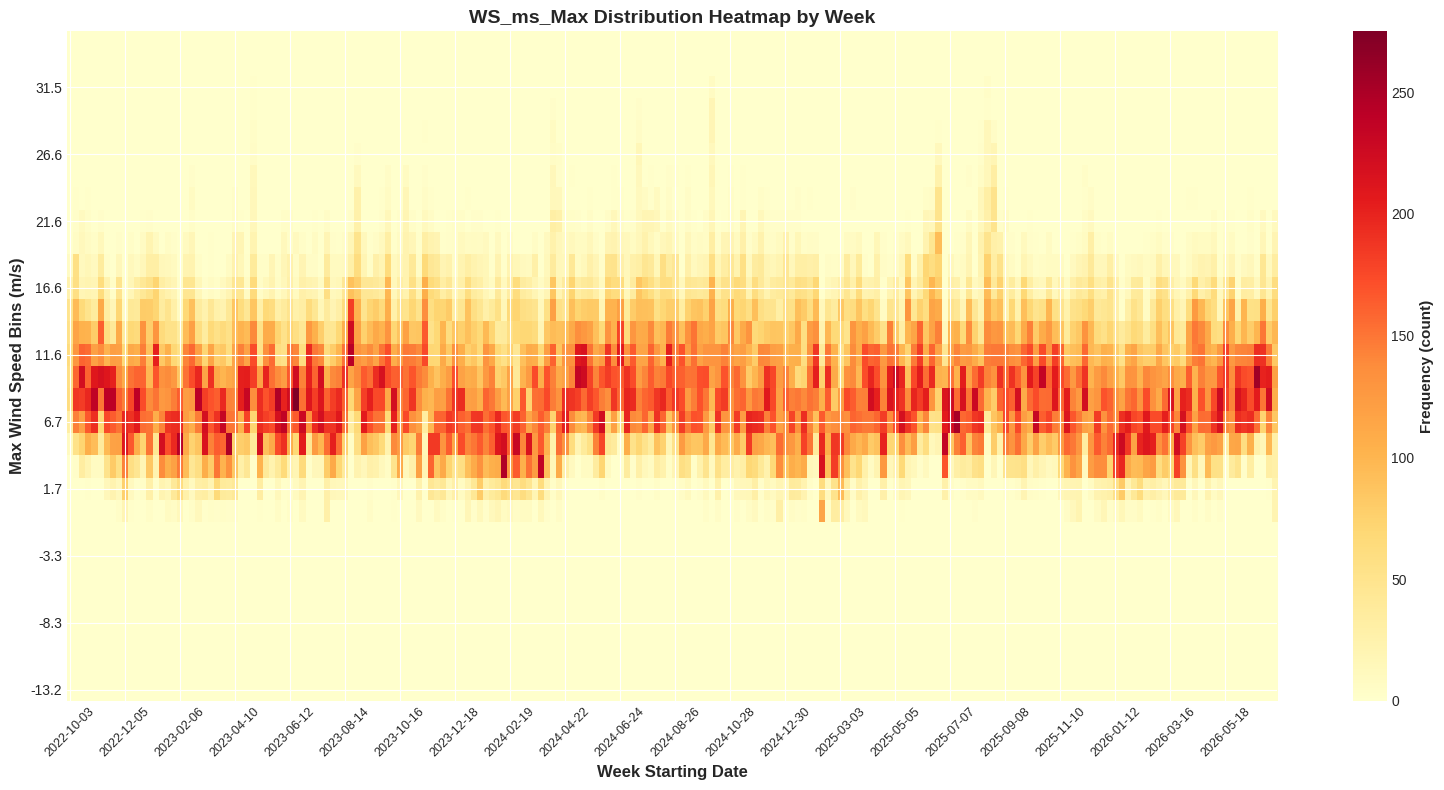

WS_ms_Max Distribution Heatmap Statistics (Weekly):
  Wind Speed Range: -14.06 to 35.69 m/s
  Number of Bins: 30
  Bin Width: 1.66 m/s
  Total Weeks: 198
  Week Range: 2022-10-03 to 2026-07-13
  Total Measurements: 198723
  Avg Measurements per Week: 1003.7


In [54]:
# Create 2D histogram heatmap: weeks on x-axis, WS_ms_Max distribution on y-axis
if 'WS_ms_Max' in df.columns:
    # Extract data
    df_temp = df[['Datetime', 'WS_ms_Max']].copy()
    
    # Remove NaN values from WS_ms_Max
    df_temp = df_temp.dropna(subset=['WS_ms_Max'])
    
    if len(df_temp) == 0:
        print("Error: No valid WS_ms_Max data available after filtering.")
        print("Please check the data filtering in the previous cell.")
    else:
        # Extract year and week from datetime
        df_temp['Year'] = df_temp['Datetime'].dt.year
        df_temp['Week'] = df_temp['Datetime'].dt.isocalendar().week
        df_temp['WeekStart'] = df_temp['Datetime'].dt.to_period('W').apply(lambda x: x.start_time)
        
        # Create week identifier (Year-Week)
        df_temp['YearWeek'] = df_temp['Year'].astype(str) + '-W' + df_temp['Week'].astype(str).str.zfill(2)
        
        # Define wind speed bins
        ws_min = df_temp['WS_ms_Max'].min()
        ws_max = df_temp['WS_ms_Max'].max()
        
        if pd.isna(ws_min) or pd.isna(ws_max) or ws_min == ws_max:
            print(f"Error: Invalid wind speed range - min: {ws_min}, max: {ws_max}")
            print("Cannot create histogram with this data range.")
        else:
            num_bins = 30
            bins = np.linspace(ws_min, ws_max, num_bins + 1)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            
            # Get unique weeks sorted
            unique_weeks = sorted(df_temp['WeekStart'].unique())
            num_weeks = len(unique_weeks)
            
            if num_weeks == 0:
                print("Error: No unique weeks found in data.")
            else:
                # Create 2D histogram array
                hist_2d = np.zeros((num_weeks, num_bins))
                
                for week_idx, week_start in enumerate(unique_weeks):
                    week_data = df_temp[df_temp['WeekStart'] == week_start]['WS_ms_Max'].values
                    hist, _ = np.histogram(week_data, bins=bins)
                    hist_2d[week_idx, :] = hist
                
                # Create figure with heatmap
                fig, ax = plt.subplots(figsize=(16, 8))
                
                # Create heatmap - transpose so weeks are on x-axis, wind speed on y-axis
                im = ax.imshow(hist_2d.T, aspect='auto', cmap='YlOrRd', interpolation='nearest', origin='lower')
                
                # Set x-axis labels (weeks)
                x_tick_interval = max(1, num_weeks // 20)  # Show ~20 week labels
                x_ticks = np.arange(0, num_weeks, x_tick_interval)
                ax.set_xticks(x_ticks)
                ax.set_xticklabels([unique_weeks[int(i)].strftime('%Y-%m-%d') for i in x_ticks], rotation=45, fontsize=9)
                
                # Set y-axis labels (wind speed bins)
                y_ticks = np.arange(0, num_bins, max(1, num_bins // 10))
                ax.set_yticks(y_ticks)
                ax.set_yticklabels([f'{bin_centers[int(i)]:.1f}' for i in y_ticks])
                
                ax.set_xlabel('Week Starting Date', fontsize=12, fontweight='bold')
                ax.set_ylabel('Max Wind Speed Bins (m/s)', fontsize=12, fontweight='bold')
                ax.set_title('WS_ms_Max Distribution Heatmap by Week', fontsize=14, fontweight='bold')
                
                # Add colorbar
                cbar = plt.colorbar(im, ax=ax)
                cbar.set_label('Frequency (count)', fontsize=11, fontweight='bold')
                
                plt.tight_layout()
                plt.show()
                
                # Print statistics
                print("WS_ms_Max Distribution Heatmap Statistics (Weekly):")
                print(f"  Wind Speed Range: {ws_min:.2f} to {ws_max:.2f} m/s")
                print(f"  Number of Bins: {num_bins}")
                print(f"  Bin Width: {(ws_max - ws_min) / num_bins:.2f} m/s")
                print(f"  Total Weeks: {num_weeks}")
                print(f"  Week Range: {unique_weeks[0].strftime('%Y-%m-%d')} to {unique_weeks[-1].strftime('%Y-%m-%d')}")
                print(f"  Total Measurements: {len(df_temp)}")
                print(f"  Avg Measurements per Week: {len(df_temp) / num_weeks:.1f}")
else:
    print("WS_ms_Max column not found in data")

## WS_ms_Max by Week and Hour of Day
Create a 2D heatmap showing maximum wind speeds with weeks on x-axis and hours of day on y-axis.

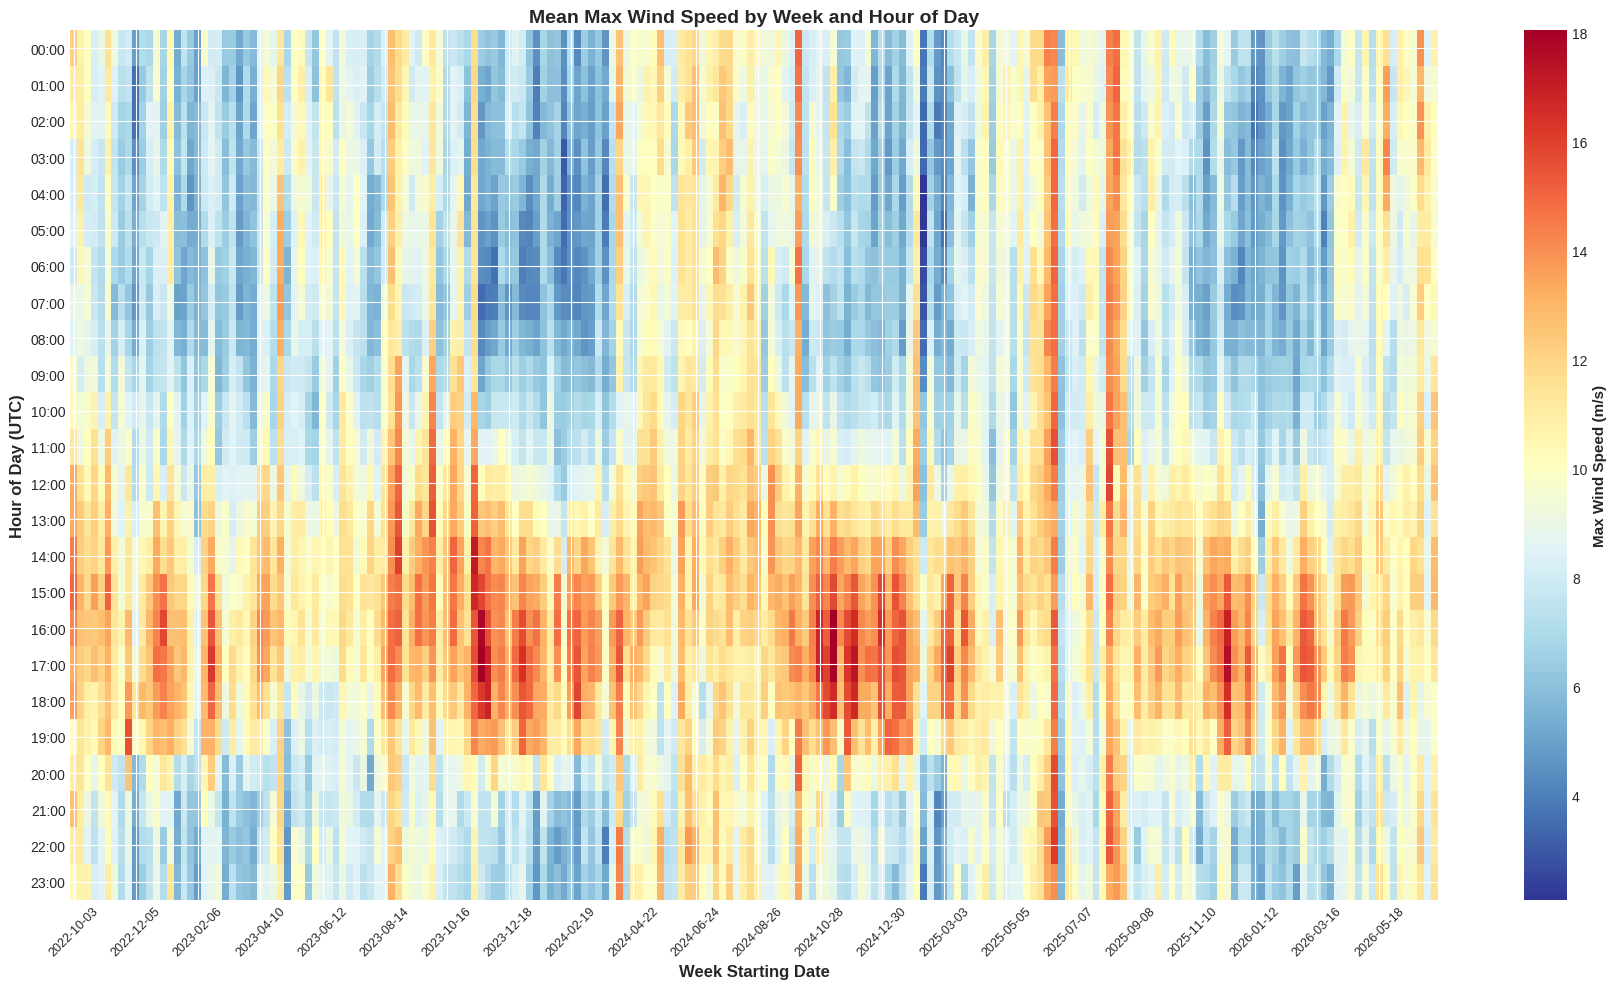

WS_ms_Max by Week and Hour Statistics:
  Total Weeks: 198
  Hours per day: 24
  Week Range: 2022-10-03 to 2026-07-13
  Total Measurements: 198723
  Data Coverage: 4752 out of 4752 cells

  Hour with Highest Avg Wind Speed: 16:00 (12.44 m/s)
  Hour with Lowest Avg Wind Speed: 08:00 (7.87 m/s)

  Overall Mean Wind Speed: 9.46 m/s
  Overall Max Wind Speed: 18.04 m/s
  Overall Min Wind Speed: 2.09 m/s


In [55]:
# Create 2D heatmap: weeks on x-axis, hours on y-axis, color = max wind speed
if 'WS_ms_Max' in df.columns:
    # Extract data
    df_temp = df[['Datetime', 'WS_ms_Max']].copy()
    
    # Remove NaN values from WS_ms_Max
    df_temp = df_temp.dropna(subset=['WS_ms_Max'])
    
    if len(df_temp) == 0:
        print("Error: No valid WS_ms_Max data available after filtering.")
    else:
        # Extract week and hour
        df_temp['WeekStart'] = df_temp['Datetime'].dt.to_period('W').apply(lambda x: x.start_time)
        df_temp['Hour'] = df_temp['Datetime'].dt.hour
        
        # Get unique weeks and hours
        unique_weeks = sorted(df_temp['WeekStart'].unique())
        num_weeks = len(unique_weeks)
        num_hours = 24
        
        if num_weeks == 0:
            print("Error: No unique weeks found in data.")
        else:
            # Create 2D array for heatmap (hours x weeks)
            heatmap_data = np.full((num_hours, num_weeks), np.nan)
            
            # Fill in the mean max wind speed for each week-hour combination
            for week_idx, week_start in enumerate(unique_weeks):
                week_mask = df_temp['WeekStart'] == week_start
                for hour in range(num_hours):
                    hour_mask = df_temp['Hour'] == hour
                    combined_mask = week_mask & hour_mask
                    
                    if combined_mask.any():
                        heatmap_data[hour, week_idx] = df_temp.loc[combined_mask, 'WS_ms_Max'].mean()
            
            # Create figure with heatmap
            fig, ax = plt.subplots(figsize=(18, 10))
            
            # Create heatmap with NaN values handled (will show as white)
            im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlBu_r', interpolation='nearest', origin='upper')
            
            # Set x-axis labels (weeks)
            x_tick_interval = max(1, num_weeks // 20)  # Show ~20 week labels
            x_ticks = np.arange(0, num_weeks, x_tick_interval)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([unique_weeks[int(i)].strftime('%Y-%m-%d') for i in x_ticks], rotation=45, fontsize=9)
            
            # Set y-axis labels (hours)
            y_ticks = np.arange(0, 24)
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([f'{h:02d}:00' for h in y_ticks])
            
            ax.set_xlabel('Week Starting Date', fontsize=12, fontweight='bold')
            ax.set_ylabel('Hour of Day (UTC)', fontsize=12, fontweight='bold')
            ax.set_title('Mean Max Wind Speed by Week and Hour of Day', fontsize=14, fontweight='bold')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label('Max Wind Speed (m/s)', fontsize=11, fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics
            print("WS_ms_Max by Week and Hour Statistics:")
            print(f"  Total Weeks: {num_weeks}")
            print(f"  Hours per day: {num_hours}")
            print(f"  Week Range: {unique_weeks[0].strftime('%Y-%m-%d')} to {unique_weeks[-1].strftime('%Y-%m-%d')}")
            print(f"  Total Measurements: {len(df_temp)}")
            print(f"  Data Coverage: {(~np.isnan(heatmap_data)).sum()} out of {num_weeks * num_hours} cells")
            
            # Find hour with highest average wind speed
            mean_by_hour = np.nanmean(heatmap_data, axis=1)
            peak_hour = np.nanargmax(mean_by_hour)
            print(f"\n  Hour with Highest Avg Wind Speed: {peak_hour:02d}:00 ({mean_by_hour[peak_hour]:.2f} m/s)")
            print(f"  Hour with Lowest Avg Wind Speed: {np.nanargmin(mean_by_hour):02d}:00 ({np.nanmin(mean_by_hour):.2f} m/s)")
            print(f"\n  Overall Mean Wind Speed: {np.nanmean(heatmap_data):.2f} m/s")
            print(f"  Overall Max Wind Speed: {np.nanmax(heatmap_data):.2f} m/s")
            print(f"  Overall Min Wind Speed: {np.nanmin(heatmap_data):.2f} m/s")
else:
    print("WS_ms_Max column not found in data")